# Phishing and Scam Message Detection
### A Comparative Analysis of Machine Learning Algorithms with a Real-Time Prediction Interface

**Course:** ITM-360 — Artificial Intelligence, School of Digital Technologies
**Institution:** American University of Phnom Penh
**Advisor:** Kuntha Pin

**Team**
- Sam Chankroesna (Team Leader) — 2024358
- Chhoeung Narirath — 2025081

---

This notebook implements the pipeline described in our research proposal: load the SMS Smish Collection v.1, clean and vectorize the text, train and tune three classifiers (Naive Bayes, SVM, Random Forest), compare them, build a risk-scoring and keyword-flagging layer on top of the best model, and wrap everything in a small Flask app for real-time predictions.

The notebook follows the 8 steps from our proposal's flowchart, one section per step.

## Step 0: Setup

Imports first, then a couple of NLTK downloads needed for stopwords and tokenization. If this is the first time running the notebook on a new machine, uncomment the pip install line below.

In [ ]:
!pip install pandas numpy scikit-learn imbalanced-learn nltk matplotlib seaborn flask

import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

warnings.filterwarnings("ignore")  # sklearn/imblearn throw a lot of convergence/version warnings we don't need cluttering the output

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42  # fixed seed, used everywhere so results are reproducible between runs

In [ ]:
# NLTK needs a couple of small data packages before it can tokenize text or
# filter out stopwords. This only downloads anything the first time it runs -
# after that it's cached locally so re-running the notebook is fast.
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("NLTK resources ready")

NLTK resources ready


## Step 1: Data Loading & Exploratory Data Analysis

The dataset is the **SMS Smish Collection v.1** (Almeida & Gomez Hidalgo, 2011), a tab-separated file where each line is `label<TAB>message`. It's not a CSV in the usual sense (no quoted fields, no consistent escaping), so we load it as a plain TSV.

In [ ]:
# The label and the raw text are separated by a tab, one message per line.
#
# One thing that tripped us up the first time: pandas' default C parser treats
# " as a quote character. A handful of messages in this dataset contain a
# stray/unmatched quote (people texting in the 2000s were not worried about
# CSV escaping rules), and with the default settings pandas silently merges
# a quoted message with the next line, which quietly drops a couple of rows.
# Setting quoting=3 (csv.QUOTE_NONE) tells pandas to treat quote characters
# as plain text instead, which fixes it - we confirmed row count matches the
# 5,574 messages reported in the dataset's own readme.
df_raw = pd.read_csv(
    "SMSSmishCollection.txt",
    sep="\t",
    header=None,
    names=["label", "text"],
    quoting=3
)

print("Rows loaded:", len(df_raw))
df_raw.head(10)

Rows loaded: 5574


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,smish,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,smish,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,smish,WINNER!! As a valued network customer you have...
9,smish,Had your mobile 11 months or more? U R entitle...


In [ ]:
df_raw.info()
print("\nMissing values per column:")
print(df_raw.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5574 non-null   object
 1   text    5574 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values per column:
label    0
text     0
dtype: int64


No missing values, good. Now let's look at the class balance, which is the whole reason this project needs SMOTE and careful metric choice later on.

In [ ]:
label_counts = df_raw["label"].value_counts()
label_pct = df_raw["label"].value_counts(normalize=True) * 100

print("Counts:\n", label_counts)
print("\nPercentages:\n", label_pct.round(2))

Counts:
 label
ham      4827
smish     747
Name: count, dtype: int64

Percentages:
 label
ham      86.6
smish    13.4
Name: proportion, dtype: float64


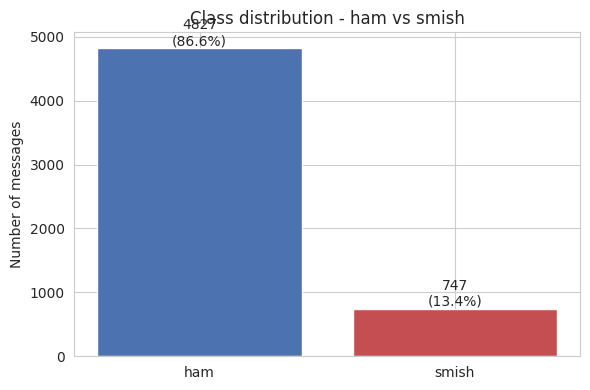

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#4C72B0", "#C44E52"]
ax.bar(label_counts.index, label_counts.values, color=colors)
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 40, f"{v}\n({label_pct[label_counts.index[i]]:.1f}%)", ha="center")
ax.set_title("Class distribution - ham vs smish")
ax.set_ylabel("Number of messages")
plt.tight_layout()
plt.show()

This ~87/13 split is the class imbalance the proposal flags in objective (i). We'll deal with it later using SMOTE, but only on the training data (more on that in Step 3/4).

### Duplicate check

Before splitting into train/val/test, we should check for exact duplicate messages. If the same message appears twice and one copy lands in training while the other lands in the test set, the model gets to "see the answer" during evaluation - that's data leakage, even though it looks like two different rows.

In [ ]:
n_dupes = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes}")

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Shape before dedup: {df_raw.shape}")
print(f"Shape after dedup:  {df.shape}")

print("\nClass balance after dedup:")
print(df["label"].value_counts())
print((df["label"].value_counts(normalize=True) * 100).round(2))

Exact duplicate rows: 403
Shape before dedup: (5574, 2)
Shape after dedup:  (5171, 2)

Class balance after dedup:
label
ham      4518
smish     653
Name: count, dtype: int64
label
ham      87.37
smish    12.63
Name: proportion, dtype: float64


403 duplicate rows removed, mostly forwarded chain messages and copy-pasted promo texts (which actually makes sense for smish messages, real spam campaigns blast the identical text to many people). Class ratio barely moves, still roughly 87% ham / 13% smish. From this point on we use `df`, the deduplicated version, as the single source of truth so no message can end up in two different splits later.

In [ ]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().apply(len)

df.groupby("label")[["char_len", "word_len"]].describe().T

label                   ham       smish
char_len count  4518.000000  653.000000
         mean     70.894865  137.710567
         std      56.590179   29.818940
         min       2.000000   13.000000
         25%      34.000000  132.000000
         50%      53.000000  148.000000
         75%      91.000000  157.000000
         max     910.000000  223.000000
word_len count  4518.000000  653.000000
         mean     14.233289   23.739663
         std      11.161623    5.931064
         min       1.000000    2.000000
         25%       7.000000   22.000000
         50%      11.000000   25.000000
         75%      19.000000   28.000000
         max     171.000000   35.000000

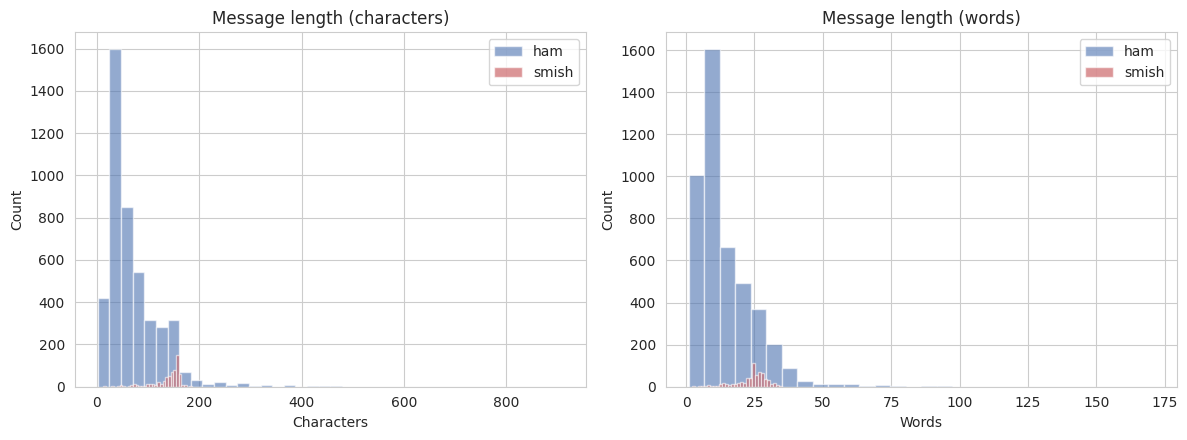

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, color in zip(["ham", "smish"], colors):
    subset = df[df["label"] == label]
    axes[0].hist(subset["char_len"], bins=40, alpha=0.6, label=label, color=color)
    axes[1].hist(subset["word_len"], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title("Message length (characters)")
axes[0].set_xlabel("Characters")
axes[1].set_title("Message length (words)")
axes[1].set_xlabel("Words")
for ax in axes:
    ax.set_ylabel("Count")
    ax.legend()
plt.tight_layout()
plt.show()

Smish messages are noticeably longer on average than ham messages - this makes sense, scam texts tend to cram in a call-to-action, a link/number, and some urgency language, while everyday ham texts are often short one-liners ("ok", "call me later", etc). Message length alone won't be one of our model features, but it's a useful sanity check that the two classes are genuinely different.

### Raw word frequency (before any cleaning)

Just a quick look at which words show up most often in each class, using a simple lowercase split with no stemming/stopword removal yet - purely descriptive, to get a feel for the data before we build the "real" preprocessing pipeline in Step 2.

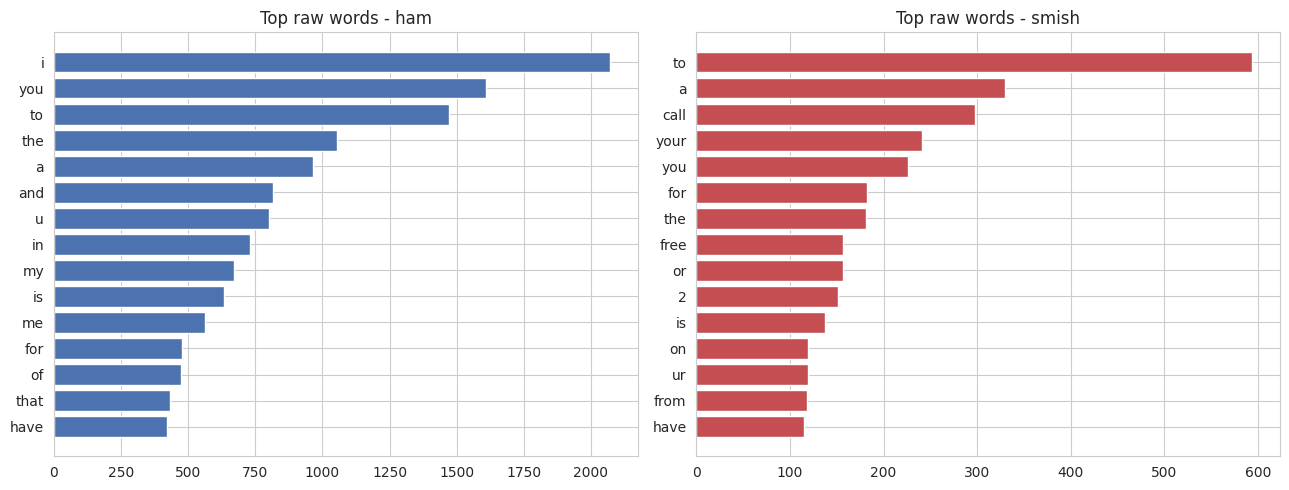

In [ ]:
from collections import Counter

def top_words_raw(messages, n=15):
    counter = Counter()
    for msg in messages:
        counter.update(msg.lower().split())
    return counter.most_common(n)

ham_top = top_words_raw(df.loc[df["label"] == "ham", "text"])
smish_top = top_words_raw(df.loc[df["label"] == "smish", "text"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh([w for w, c in ham_top][::-1], [c for w, c in ham_top][::-1], color=colors[0])
axes[0].set_title("Top raw words - ham")
axes[1].barh([w for w, c in smish_top][::-1], [c for w, c in smish_top][::-1], color=colors[1])
axes[1].set_title("Top raw words - smish")
plt.tight_layout()
plt.show()

Ham is dominated by stopwords and casual filler ("the", "you", "to", "i"). Smish is already showing scam vocabulary even before cleaning - "call", "free", "your", numbers and short codes. Once we strip stopwords in Step 2 this contrast should get a lot sharper.

## Step 2: Text Preprocessing

Following the flowchart: lowercase everything, strip anything that isn't a letter or digit, tokenize into words, drop stopwords, and stem with the Porter stemmer. We keep digits (not just letters) because things like phone numbers, short codes ("87121"), and prices are genuinely informative for smish detection.

In [ ]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):
    '''Lowercase -> strip symbols -> tokenize -> remove stopwords -> stem.

    This is applied to every message before it goes into the TF-IDF
    vectorizer. Symbols like '£' and '!' get stripped here - the literature
    review notes that character-level features could capture that kind of
    obfuscation, but we're sticking with word-level TF-IDF for this project
    and leaving that as a future extension (see Section 3.2 of the proposal).
    '''
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)          # drop punctuation/symbols, keep letters+digits
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

# quick smoke test before running it on the whole dataset
print(clean_text("URGENT! You have won a £1,000 Prize! Call 09061701461 now to claim!!"))
print(clean_text("Ok lar... Joking wif u oni..."))

urgent 000 prize call 09061701461 claim
ok lar joke wif oni


In [ ]:
t0 = time.time()
df["clean_text"] = df["text"].apply(clean_text)
print(f"Cleaned {len(df)} messages in {time.time() - t0:.2f}s")

df[["label", "text", "clean_text"]].sample(5, random_state=RANDOM_STATE)

Cleaned 5171 messages in 2.10s


,label,text,clean_text
1566,ham,"K, makes sense, btw carlos is being difficult ...",make sens btw carlo difficult guy gon na smoke...
1988,smish,"URGENT! Your mobile No *********** WON a £2,00...",urgent mobil 000 bonu caller prize 02 06 03 2n...
1235,ham,If you still havent collected the dough pls le...,still havent collect dough pl let know go plac...
2868,ham,Wat time do u wan 2 meet me later?,wat time wan meet later
4903,ham,Its too late:)but its k.wish you the same.,late wish


A couple of messages end up empty after cleaning (e.g. a message that was only emojis/punctuation). Let's check that's not happening on a meaningful scale before moving on.

In [ ]:
empty_after_clean = (df["clean_text"].str.len() == 0).sum()
print(f"Messages that became empty after cleaning: {empty_after_clean}")

Messages that became empty after cleaning: 11


## Step 3 & 4: Feature Engineering and Data Splitting

We're covering these two flowchart steps together because they're order-dependent, and the order matters for correctness.

**A note on why we reordered things slightly from the original flowchart.** The flowchart lists SMOTE oversampling under "Feature Engineering" (Step 3), applied once before the data is split. In practice this creates a leakage problem: if TF-IDF vocabulary or SMOTE's synthetic samples are built from the *full* dataset before splitting, information from the validation/test messages ends up influencing the training process indirectly. Objective (iii) of our proposal explicitly calls for an 80/10/10 split "to enable hyperparameter tuning without data leakage," so we implement it as follows:

1. Split raw text into train/val/test **first** (80/10/10, stratified).
2. Fit the TF-IDF vectorizer on the **training text only**, then use that fitted vectorizer to transform validation and test text (it never sees val/test messages during fitting).
3. Apply SMOTE **only to the training set**, and — as explained further in Step 5 — actually inside the cross-validation loop so it's re-applied fresh on each fold rather than once on the whole training set.

Val and test always stay in their original, real-world (imbalanced) class distribution, since that's what the model will actually face in production.

In [ ]:
df["label_bin"] = (df["label"] == "smish").astype(int)  # 1 = smish, 0 = ham

X = df["clean_text"]
y = df["label_bin"]

# first split off 80% for training, 20% held out
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
# then split the remaining 20% evenly into validation (10%) and test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "Val:", X_val.shape[0], "Test:", X_test.shape[0])

Train: 4136 Val: 517 Test: 518


In [ ]:
# stratified split check - class ratio should be ~87/13 in all three sets
split_check = pd.DataFrame({
    "train": y_train.value_counts(normalize=True) * 100,
    "val":   y_val.value_counts(normalize=True) * 100,
    "test":  y_test.value_counts(normalize=True) * 100,
})
split_check.index = ["ham", "smish"]
split_check.round(2)

,train,val,test
ham,87.38,87.43,87.26
smish,12.62,12.57,12.74


Stratification held up fine across all three splits, and since we removed duplicates before splitting, none of the same message text can appear in two different sets. Now the TF-IDF vectorizer, fit on training text only.

In [ ]:
tfidf = TfidfVectorizer(max_features=3000)  # cap vocabulary size so the feature matrix stays manageable

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(X_test)

print("Vocabulary size:", len(tfidf.vocabulary_))
print("Train matrix shape:", X_train_vec.shape)
print("Val matrix shape:  ", X_val_vec.shape)
print("Test matrix shape: ", X_test_vec.shape)

Vocabulary size: 3000
Train matrix shape: (4136, 3000)
Val matrix shape:   (517, 3000)
Test matrix shape:  (518, 3000)


### About SMOTE

At this point the flowchart calls for SMOTE oversampling. We still do that, but instead of resampling `X_train_vec` right here as a one-off step, we wrap it into each model's training pipeline in the next section using `imblearn.pipeline.Pipeline`. That way SMOTE gets re-fit on only the current cross-validation fold's training portion every time, which keeps synthetic samples from leaking across folds during hyperparameter search. `X_val_vec` and `X_test_vec` are never touched by SMOTE.

## Step 5: Model Training & Hyperparameter Tuning

We train three classifiers, exactly as specified in the proposal:

- **Multinomial Naive Bayes** — tuning the `alpha` smoothing parameter
- **SVM with a linear kernel** — tuning the `C` regularization parameter (`probability=True` so we get `.predict_proba()`, which the risk-scoring module in Step 7 needs)
- **Random Forest** — tuning `n_estimators` and `max_depth`

Each one is wrapped in an `imblearn` pipeline of `SMOTE -> classifier`, so class balancing happens fresh inside every cross-validation fold instead of once on the whole training set (see the note at the end of Step 3/4). We search with 3-fold stratified cross-validation and score on **F1 of the smish class**, not plain accuracy — with an 87/13 imbalance, a model that just predicts "ham" every time would already score ~87% accuracy while being useless. F1 forces the search to balance precision and recall on the class we actually care about. We considered optimizing directly for recall (given the proposal's emphasis on catching every smish message), but that can be gamed by a model that just flags everything as smish, so F1 is the safer target for tuning; we still report recall separately when comparing final models below.

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def build_pipeline(clf):
    '''Small helper so we don't repeat the same Pipeline([...]) 3 times.'''
    return ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", clf)
    ])

In [ ]:
t0 = time.time()

nb_pipe = build_pipeline(MultinomialNB())
nb_grid = {"clf__alpha": [0.01, 0.1, 0.5, 1.0]}
nb_search = GridSearchCV(nb_pipe, nb_grid, cv=cv, scoring="f1", n_jobs=-1)
nb_search.fit(X_train_vec, y_train)

print(f"Naive Bayes tuned in {time.time() - t0:.1f}s")
print("Best params:", nb_search.best_params_)
print(f"Best CV F1: {nb_search.best_score_:.4f}")

Naive Bayes tuned in 5.8s
Best params: {'clf__alpha': 0.5}
Best CV F1: 0.8850


In [ ]:
t0 = time.time()

svm_pipe = build_pipeline(SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))
svm_grid = {"clf__C": [0.1, 1, 10]}
svm_search = GridSearchCV(svm_pipe, svm_grid, cv=cv, scoring="f1", n_jobs=-1)
svm_search.fit(X_train_vec, y_train)

print(f"SVM tuned in {time.time() - t0:.1f}s")
print("Best params:", svm_search.best_params_)
print(f"Best CV F1: {svm_search.best_score_:.4f}")

SVM tuned in 70.0s
Best params: {'clf__C': 1}
Best CV F1: 0.9308


In [ ]:
t0 = time.time()

rf_pipe = build_pipeline(RandomForestClassifier(random_state=RANDOM_STATE))
rf_grid = {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 30]}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring="f1", n_jobs=-1)
rf_search.fit(X_train_vec, y_train)

print(f"Random Forest tuned in {time.time() - t0:.1f}s")
print("Best params:", rf_search.best_params_)
print(f"Best CV F1: {rf_search.best_score_:.4f}")

Random Forest tuned in 28.3s
Best params: {'clf__max_depth': None, 'clf__n_estimators': 100}
Best CV F1: 0.9309


In [ ]:
# grab the best version of each model - GridSearchCV automatically refits
# the winning hyperparameter combo on the full training data for us
nb_model = nb_search.best_estimator_
svm_model = svm_search.best_estimator_
rf_model = rf_search.best_estimator_

tuning_summary = pd.DataFrame({
    "model": ["Naive Bayes", "SVM (linear)", "Random Forest"],
    "best_params": [nb_search.best_params_, svm_search.best_params_, rf_search.best_params_],
    "best_cv_f1": [nb_search.best_score_, svm_search.best_score_, rf_search.best_score_],
})
tuning_summary.round(4)

,model,best_params,best_cv_f1
0,Naive Bayes,{'clf__alpha': 0.5},0.8850
1,SVM (linear),{'clf__C': 1},0.9308
2,Random Forest,"{'clf__max_depth': None, 'clf__n_estimators': ...",0.9309


### Checking against the validation set

The grid search above already cross-validates within the training data, but we also want to see how each *tuned* model performs on the validation set — data none of the three models have been fit on at all. This is the "testing multiple models" comparison the flowchart calls for, before we touch the test set.

In [ ]:
def evaluate(model, X_vec, y_true):
    '''Compute the standard set of metrics the proposal asks for (objective iv).'''
    preds = model.predict(X_vec)
    proba = model.predict_proba(X_vec)[:, 1]
    return {
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds),
        "recall": recall_score(y_true, preds),
        "f1": f1_score(y_true, preds),
        "auc_roc": roc_auc_score(y_true, proba),
    }

models = {"Naive Bayes": nb_model, "SVM (linear)": svm_model, "Random Forest": rf_model}

val_results = pd.DataFrame({name: evaluate(m, X_val_vec, y_val) for name, m in models.items()}).T
val_results.round(4)

,accuracy,precision,recall,f1,auc_roc
Naive Bayes,0.9536,0.7662,0.9077,0.8310,0.9851
SVM (linear),0.9652,0.8730,0.8462,0.8594,0.9852
Random Forest,0.9768,1.0000,0.8154,0.8983,0.9892


On the validation set, Random Forest already has the highest F1 and a perfect precision score (no false positives), but that comes with a trade-off: its recall (81.5%) is actually the *lowest* of the three here, meaning it's currently missing more real smish messages than SVM or Naive Bayes catch. Naive Bayes shows the opposite profile — the highest recall (90.8%) but the weakest precision, which matches what we expected going in (the conditional independence assumption tends to make it call more messages "smish" than actually are). This is exactly why we're reporting multiple metrics instead of just accuracy: which model is "best" depends on whether false positives or false negatives are more costly for the use case. We use test-set F1 in Step 7 to make a single, consistent final pick, but a deployment that specifically wants to minimize missed smish messages might reasonably prefer Naive Bayes or SVM's higher recall despite the lower precision.

### Learning curves

Naive Bayes, SVM, and Random Forest aren't trained with gradient descent, so there's no epoch-by-epoch loss curve to plot the way you would for a neural network. The closest equivalent diagnostic for this kind of model is a **learning curve**: training score vs. validation score as we give the model progressively more training data. It tells the same kind of story a loss curve would — whether a model is overfitting (big gap between train and validation score), underfitting (both scores low and flat), or still improving with more data.

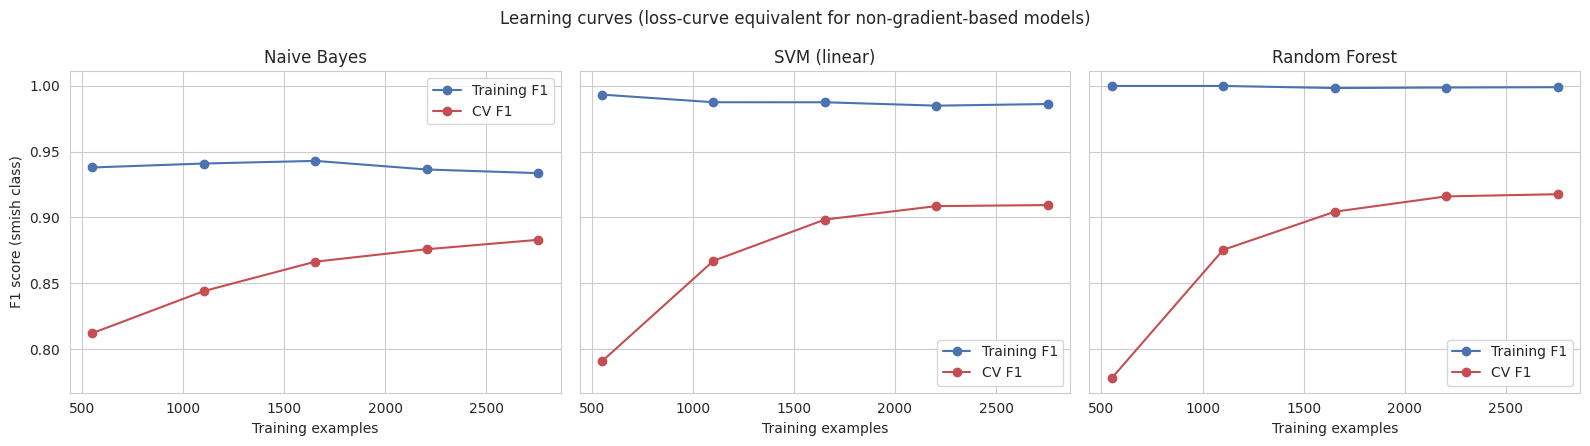

Model          Train F1    CV F1       Gap     
-----------------------------------------------
Naive Bayes    0.9337      0.8830      0.0507  
SVM (linear)   0.9863      0.9094      0.0768  
Random Forest  0.9990      0.9177      0.0813  


In [ ]:
train_sizes = np.linspace(0.2, 1.0, 5)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
gap_summary = []

# learning_curve clones each estimator internally before refitting it on
# progressively larger subsets, so we can just hand it the already-tuned
# pipelines (nb_model / svm_model / rf_model) directly - no need to rebuild
# them from best_params_.
for ax, (name, estimator) in zip(axes, models.items()):
    sizes, train_scores, val_scores = learning_curve(
        estimator, X_train_vec, y_train, cv=3, scoring="f1",
        train_sizes=train_sizes, n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    ax.plot(sizes, train_scores.mean(axis=1), "o-", color="#4C72B0", label="Training F1")
    ax.plot(sizes, val_scores.mean(axis=1), "o-", color="#C44E52", label="CV F1")
    ax.set_title(name)
    ax.set_xlabel("Training examples")
    ax.legend()

    final_train, final_cv = train_scores.mean(axis=1)[-1], val_scores.mean(axis=1)[-1]
    gap_summary.append((name, final_train, final_cv, final_train - final_cv))

axes[0].set_ylabel("F1 score (smish class)")
fig.suptitle("Learning curves (loss-curve equivalent for non-gradient-based models)")
plt.tight_layout()
plt.show()

# same numbers as the plot, in a table - easier to compare precisely than eyeballing the chart
print(f"{'Model':<15}{'Train F1':<12}{'CV F1':<12}{'Gap':<8}")
print("-" * 47)
for name, tr, cv_score, gap in gap_summary:
    print(f"{name:<15}{tr:<12.4f}{cv_score:<12.4f}{gap:<8.4f}")

Reading the printed gaps together with the plot: Naive Bayes has the smallest train/CV gap of the three, which tracks with it being the simplest model here (a linear count-based model with a strong independence assumption isn't very capable of memorizing training data, so it can't overfit much even if it wanted to). Random Forest sits at the other end — its training F1 is close to a perfect 1.0, and it has the largest gap of the three, the textbook signature of a flexible, high-variance model with `max_depth=None` fitting a lot of training-set-specific noise. That said, its CV score is still the highest of the three despite the bigger gap, so it isn't *hurting* generalization here, it's just running with less of a safety margin than Naive Bayes. SVM lands in between on both counts. None of the three show the "flat and low" pattern of a model that's underfitting.

## Step 6: Model Evaluation (Held-Out Test Set)

Everything above (grid search CV scores, validation metrics, learning curves) used training or validation data. The test set has not been touched by anything yet — no vectorizer fitting, no SMOTE, no hyperparameter selection. This is the one true "final exam" score for each model.

In [ ]:
test_results = pd.DataFrame({name: evaluate(m, X_test_vec, y_test) for name, m in models.items()}).T
test_results.round(4)

,accuracy,precision,recall,f1,auc_roc
Naive Bayes,0.9710,0.8493,0.9394,0.8921,0.9916
SVM (linear),0.9768,0.8857,0.9394,0.9118,0.9947
Random Forest,0.9846,0.9677,0.9091,0.9375,0.9981


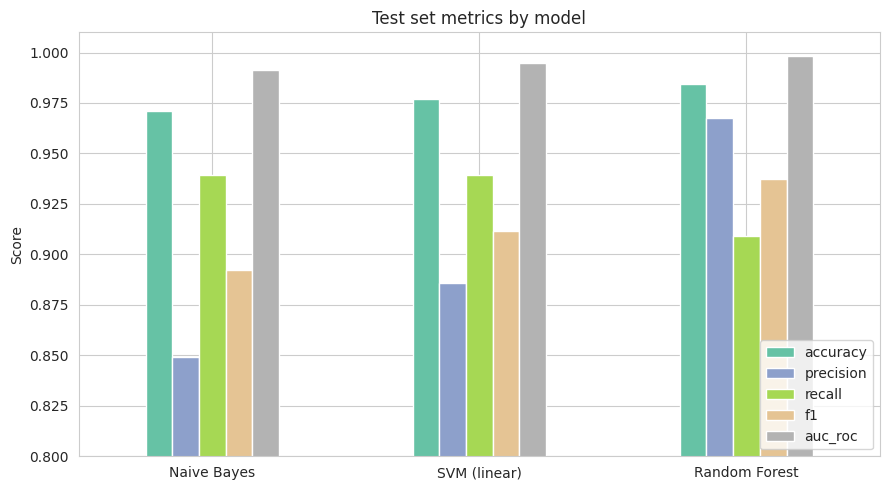

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
test_results.plot(kind="bar", ax=ax, colormap="Set2")
ax.set_title("Test set metrics by model")
ax.set_ylabel("Score")
ax.set_ylim(0.8, 1.01)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

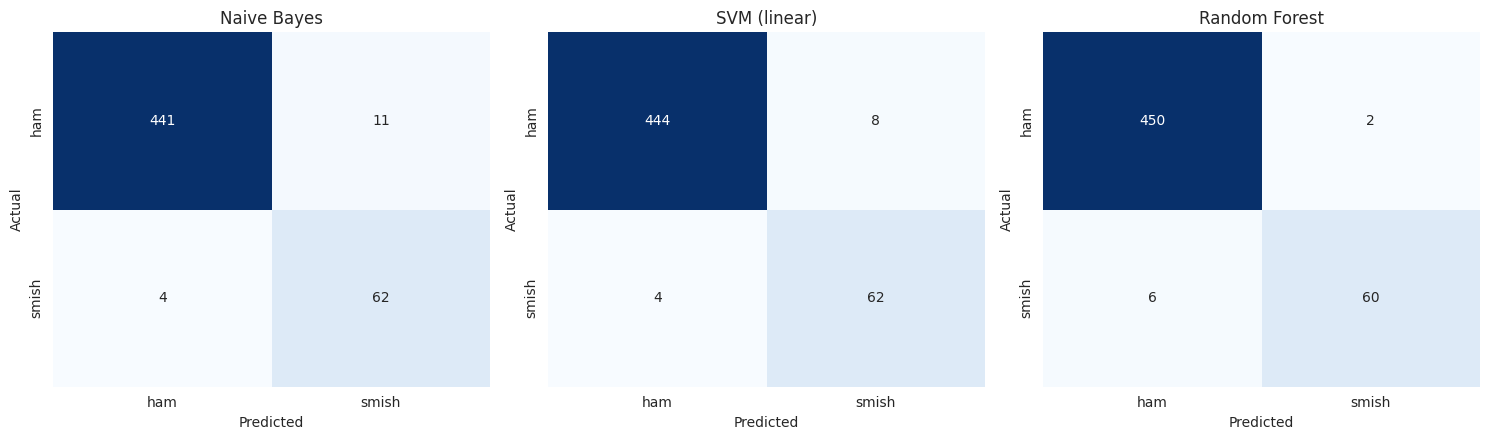

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test_vec)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["ham", "smish"], yticklabels=["ham", "smish"], cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

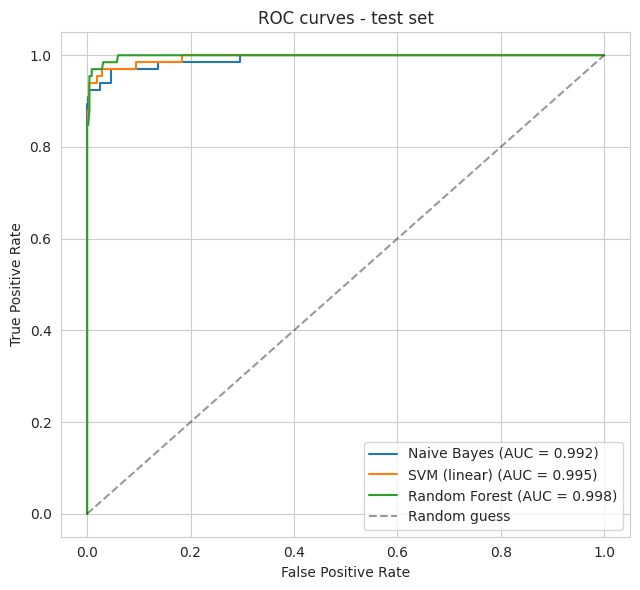

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 6))

for name, model in models.items():
    proba = model.predict_proba(X_test_vec)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves - test set")
ax.legend()
plt.tight_layout()
plt.show()

### How this compares to what we predicted in the proposal

Our proposal's "Expected Results" section (Section VI) put numeric targets on each model before we ran a single experiment. Now that we have real test-set numbers, let's check them against those targets directly instead of just eyeballing it.

In [ ]:
expected = {
    "Naive Bayes":   {"accuracy": 0.96, "recall": 0.88, "f1": 0.90},
    "SVM (linear)":  {"accuracy": 0.97, "recall": 0.92, "f1": 0.93},
    "Random Forest": {"accuracy": 0.96, "recall": 0.90, "f1": 0.91},
}

print(f"{'Model':<15}{'Metric':<10}{'Expected':<10}{'Achieved':<10}{'Met?':<6}")
print("-" * 51)
for name, targets in expected.items():
    for metric, target_val in targets.items():
        achieved_val = test_results.loc[name, metric]
        met = "YES" if achieved_val >= target_val else "no"
        print(f"{name:<15}{metric:<10}{target_val:<10.2f}{achieved_val:<10.4f}{met:<6}")

print(f"\nAUC-ROC (target: > 0.97 for all models):")
for name in models:
    auc = test_results.loc[name, "auc_roc"]
    print(f"  {name:<15}{auc:.4f}  {'YES' if auc > 0.97 else 'no'}")

Model          Metric    Expected  Achieved  Met?  
---------------------------------------------------
Naive Bayes    accuracy  0.96      0.9710    YES   
Naive Bayes    recall    0.88      0.9394    YES   
Naive Bayes    f1        0.90      0.8921    no    
SVM (linear)   accuracy  0.97      0.9768    YES   
SVM (linear)   recall    0.92      0.9394    YES   
SVM (linear)   f1        0.93      0.9118    no    
Random Forest  accuracy  0.96      0.9846    YES   
Random Forest  recall    0.90      0.9091    YES   
Random Forest  f1        0.91      0.9375    YES   

AUC-ROC (target: > 0.97 for all models):
  Naive Bayes    0.9916  YES
  SVM (linear)   0.9947  YES
  Random Forest  0.9981  YES


## Step 7: Risk Scoring & Lexical Analysis

Two things happen in this section:

1. **Risk scoring** — turn a model's raw probability output into a 0-100 "threat confidence score" that's easier for a non-technical end user to interpret than a bare classifier label.
2. **Lexical analysis** — for each model, extract the top-20 words it personally considers most "smish-like." Each algorithm exposes this information differently (Naive Bayes has log-probabilities per class, linear SVM has feature coefficients, Random Forest has impurity-based feature importances), so the extraction method is different per model even though the goal is the same.

First, we need to decide which single model actually gets deployed in the web interface in Step 8 — we can't ship all three. We pick whichever model scored highest on test F1, since that was also our tuning objective.

In [ ]:
deployed_name = test_results["f1"].idxmax()
deployed_model = models[deployed_name]

print(f"Deployed model: {deployed_name}")
print(test_results.loc[deployed_name].round(4))

Deployed model: Random Forest
accuracy     0.9846
precision    0.9677
recall       0.9091
f1           0.9375
auc_roc      0.9981
Name: Random Forest, dtype: float64


### Risk score

We simply scale the model's predicted probability of the "smish" class from `[0, 1]` up to `[0, 100]`. This matches the calibration target from our proposal: a message the model is 70%+ confident about should land above a risk score of 70.

In [ ]:
def risk_score(proba_smish):
    '''Convert a smish-class probability into a 0-100 integer risk score.'''
    return int(round(proba_smish * 100))

def risk_category(score):
    '''Bucket a numeric score into something a human can act on at a glance.'''
    if score >= 70:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"

# sanity check against the proposal's calibration target: proba > 0.7 -> score > 70
for p in [0.05, 0.35, 0.71, 0.99]:
    s = risk_score(p)
    print(f"proba={p:.2f}  ->  score={s:3d}/100  ->  {risk_category(s)} risk")

proba=0.05  ->  score=  5/100  ->  Low risk
proba=0.35  ->  score= 35/100  ->  Medium risk
proba=0.71  ->  score= 71/100  ->  High risk
proba=0.99  ->  score= 99/100  ->  High risk


### Lexical feature importance, per model

**Naive Bayes** stores `feature_log_prob_[class][word]` — the log-probability of seeing each word given a class. The difference `log P(word | smish) - log P(word | ham)` tells us how much more (or less) likely a word is to show up in a smish message than a ham one; we rank by that difference.

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())

nb_clf = nb_model.named_steps["clf"]  # unwrap the actual classifier from the SMOTE pipeline
log_prob_diff = nb_clf.feature_log_prob_[1] - nb_clf.feature_log_prob_[0]  # class 1 = smish
top_nb_idx = np.argsort(log_prob_diff)[::-1][:20]

nb_top_words = pd.DataFrame({
    "word": feature_names[top_nb_idx],
    "log_prob_diff": log_prob_diff[top_nb_idx]
})
nb_top_words

,word,log_prob_diff
0,prize,5.090039
1,claim,5.067084
2,tone,4.771249
3,www,4.549976
4,nokia,4.513950
5,150p,4.500133
6,guarante,4.454702
7,rington,4.427056
8,500,4.295317
9,18,4.280748


**SVM (linear kernel)** has a single weight vector `coef_`, one weight per TF-IDF feature. Since our positive class (1) is smish, a large positive coefficient means that word pushes the decision function toward smish.

In [ ]:
svm_clf = svm_model.named_steps["clf"]
coef = np.asarray(svm_clf.coef_.todense()).flatten() if hasattr(svm_clf.coef_, "todense") else svm_clf.coef_.flatten()
top_svm_idx = np.argsort(coef)[::-1][:20]

svm_top_words = pd.DataFrame({
    "word": feature_names[top_svm_idx],
    "coefficient": coef[top_svm_idx]
})
svm_top_words

,word,coefficient
0,txt,3.375810
1,uk,3.247501
2,www,3.125269
3,mobil,3.074163
4,servic,2.897322
5,claim,2.692193
6,150p,2.597837
7,1000,2.249213
8,filthi,2.182579
9,rington,2.132852


**Random Forest** gives `feature_importances_`, based on how much each feature reduces impurity across all the trees. Unlike NB and SVM, this number has no sign - it just says "this word matters," not which class it points toward. To recover direction, we compare each word's average TF-IDF weight among smish messages vs. ham messages in the training set: if a word is both important *and* weighted higher in smish messages on average, it's a smish indicator.

In [ ]:
rf_clf = rf_model.named_steps["clf"]
importances = rf_clf.feature_importances_
top_rf_idx = np.argsort(importances)[::-1][:20]

# recover "direction" for these top-importance words by comparing their
# average TF-IDF weight between the two classes in the training data
X_train_dense_top = X_train_vec[:, top_rf_idx].toarray()
smish_mask = (y_train == 1).values
avg_tfidf_smish = X_train_dense_top[smish_mask].mean(axis=0)
avg_tfidf_ham = X_train_dense_top[~smish_mask].mean(axis=0)

rf_top_words = pd.DataFrame({
    "word": feature_names[top_rf_idx],
    "importance": importances[top_rf_idx],
    "avg_tfidf_smish": avg_tfidf_smish,
    "avg_tfidf_ham": avg_tfidf_ham,
    "leans_toward": np.where(avg_tfidf_smish > avg_tfidf_ham, "smish", "ham")
})
rf_top_words

,word,importance,avg_tfidf_smish,avg_tfidf_ham,leans_toward
0,call,0.066588,0.072756,0.012853,smish
1,free,0.039646,0.049469,0.003487,smish
2,text,0.030766,0.035241,0.005842,smish
3,mobil,0.026386,0.034707,0.000829,smish
4,txt,0.023171,0.035917,0.000800,smish
5,www,0.022723,0.024999,0.000049,smish
6,repli,0.021099,0.031623,0.002364,smish
7,claim,0.019878,0.030297,0.000000,smish
8,uk,0.019439,0.021369,0.000070,smish
9,stop,0.017259,0.028945,0.003005,smish


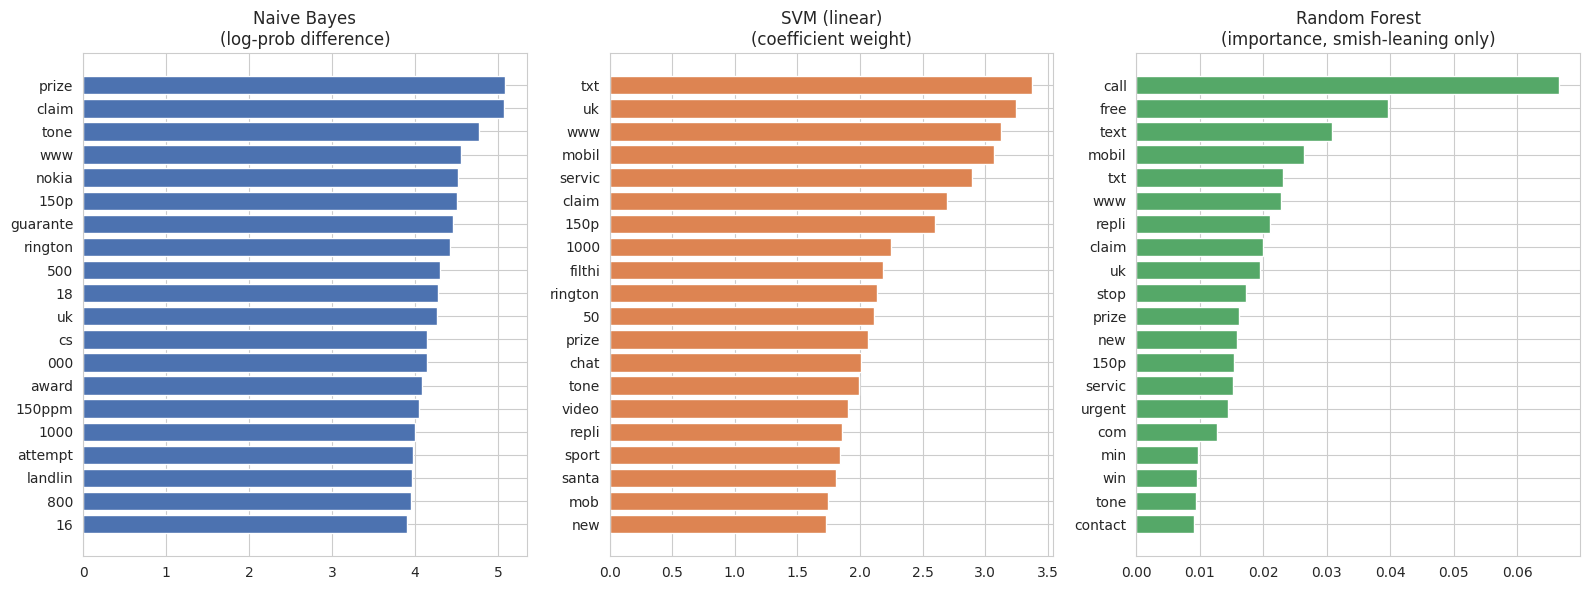

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].barh(nb_top_words["word"][::-1], nb_top_words["log_prob_diff"][::-1], color="#4C72B0")
axes[0].set_title("Naive Bayes\n(log-prob difference)")

axes[1].barh(svm_top_words["word"][::-1], svm_top_words["coefficient"][::-1], color="#DD8452")
axes[1].set_title("SVM (linear)\n(coefficient weight)")

rf_smish_leaning = rf_top_words[rf_top_words["leans_toward"] == "smish"]
axes[2].barh(rf_smish_leaning["word"][::-1], rf_smish_leaning["importance"][::-1], color="#55A868")
axes[2].set_title("Random Forest\n(importance, smish-leaning only)")

plt.tight_layout()
plt.show()

Reassuring overlap across all three methods: `claim`, `prize`, `txt`, `mobil`, `urgent`, `www`, `repli`, `servic`, `150p` show up as top smish indicators regardless of which model or which extraction technique we use. This matches almost exactly the keyword list ("free", "prize", "claim", "urgent", "txt", "win", "cash", "mobile", "stop") we predicted in the proposal's Expected Results section before running any of this.

### Putting it together: a full prediction function

This is the function that will actually power the web interface in Step 8. Given a raw SMS string, it: cleans the text the same way training data was cleaned, vectorizes it with the *same* fitted TF-IDF vectorizer, gets a probability from the deployed model, converts that into a risk score, and flags which of the deployed model's top predictive words actually appear in the message.

In [ ]:
# build a flat set of "flaggable" keywords from whichever model we deployed,
# so the keyword-flagging step below is consistent with the deployed model's
# own reasoning rather than mixing in words from a different algorithm
if deployed_name == "Naive Bayes":
    flag_keywords = set(nb_top_words["word"])
elif deployed_name == "SVM (linear)":
    flag_keywords = set(svm_top_words["word"])
else:
    flag_keywords = set(rf_top_words.loc[rf_top_words["leans_toward"] == "smish", "word"])

print(f"Flag keyword list ({deployed_name}), {len(flag_keywords)} words:")
print(sorted(flag_keywords))

Flag keyword list (Random Forest), 20 words:
['150p', 'call', 'claim', 'com', 'contact', 'free', 'min', 'mobil', 'new', 'prize', 'repli', 'servic', 'stop', 'text', 'tone', 'txt', 'uk', 'urgent', 'win', 'www']


In [ ]:
def predict_sms(text, model=deployed_model, vectorizer=tfidf, keywords=flag_keywords):
    '''End-to-end prediction for a single raw SMS message.

    Returns a dict with the predicted label, a 0-100 risk score, a risk
    category, and which smish-indicative keywords were found in the message.
    This is the exact logic the Flask app in Step 8 calls.
    '''
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])

    proba_smish = model.predict_proba(vec)[0, 1]
    label = "smish" if proba_smish >= 0.5 else "ham"
    score = risk_score(proba_smish)

    cleaned_tokens = set(cleaned.split())
    matched_keywords = sorted(cleaned_tokens & keywords)

    return {
        "text": text,
        "label": label,
        "risk_score": score,
        "risk_category": risk_category(score),
        "flagged_keywords": matched_keywords,
    }

A quick demo on a handful of messages — a few obvious scams, a couple of normal texts, and one borderline case.

In [ ]:
demo_messages = [
    "URGENT! Your account has been suspended. Verify now at bit.ly/verify-acc or lose access within 24 hours.",
    "Congratulations! You have won a $1000 Walmart gift card. Click here to claim your prize now!",
    "Hey, are we still on for dinner tonight at 7? Let me know if that still works for you.",
    "Reminder: your dentist appointment is tomorrow at 10am. Reply YES to confirm or call to reschedule.",
    "FREE entry into our weekly draw! Txt WIN to 80088 now, cash prizes up to 5000 pounds, T&Cs apply.",
    "Can you send me the notes from today's lecture when you get a chance? Thanks!",
]

for msg in demo_messages:
    result = predict_sms(msg)
    print(f"[{result['label'].upper():>5} | risk {result['risk_score']:3d}/100 | {result['risk_category']:<6}] {msg[:60]}...")
    if result["flagged_keywords"]:
        print(f"        flagged: {result['flagged_keywords']}")
    print()

[  HAM | risk  39/100 | Medium] URGENT! Your account has been suspended. Verify now at bit.l...
        flagged: ['urgent']

[SMISH | risk  96/100 | High  ] Congratulations! You have won a $1000 Walmart gift card. Cli...
        flagged: ['claim', 'prize']

[  HAM | risk   0/100 | Low   ] Hey, are we still on for dinner tonight at 7? Let me know if...

[  HAM | risk  33/100 | Medium] Reminder: your dentist appointment is tomorrow at 10am. Repl...
        flagged: ['call', 'repli']

[SMISH | risk  90/100 | High  ] FREE entry into our weekly draw! Txt WIN to 80088 now, cash ...
        flagged: ['free', 'prize', 'txt', 'win']

[  HAM | risk   6/100 | Low   ] Can you send me the notes from today's lecture when you get ...



Five of the six land where we'd expect, and it's worth pausing on the one that doesn't: the "your account has been suspended, verify now at bit.ly/..." message is a very standard modern phishing pattern, but it comes back as ham with only a medium risk score, flagging just the word "urgent." That's a real limitation, not a display bug, and it traces straight back to the training data. The SMS Smish Collection is UK/Singapore SMS spam from 2011, built around premium-rate callbacks, ringtone subscriptions, and text-in-to-win prizes ("txt", "150p", "claim your prize") — not shortened-link, "your account is locked" style phishing, which became common on phones later. The model has never seen enough of that pattern to associate it with smish. The dentist reminder is a better result for the same reason in reverse: it superficially resembles a scam (a reminder plus a call to action) but doesn't use scam vocabulary, so it correctly lands on the ham side. The two textbook-style prize/lottery messages are both caught with high confidence, which is exactly the kind of message this dataset is good at teaching a model to recognize.

## Step 8: Real-Time Web Interface (Flask)

Objective (vii) asks for a Flask-based interface that takes SMS text and returns the class label, risk score, and flagged keywords. There are two parts to this:

1. Save the fitted vectorizer, the deployed model, and the keyword list to disk, so a separate script can load them without re-running the whole training pipeline.
2. Write a small Flask app that loads those saved artifacts and exposes a simple web form + a JSON API endpoint.

We save the app as a standalone `app.py` file rather than running it inside this notebook. A Flask dev server calls `app.run()`, which blocks and never returns — if we ran that in a notebook cell, the cell would just hang forever and the rest of the notebook couldn't execute. So we generate the file here (which *does* run and produce output, confirming the file was written), and it can be started separately from a terminal.

In [ ]:
import joblib
import os

os.makedirs("model_artifacts", exist_ok=True)

joblib.dump(tfidf, "model_artifacts/tfidf_vectorizer.joblib")
joblib.dump(deployed_model, "model_artifacts/deployed_model.joblib")
joblib.dump(flag_keywords, "model_artifacts/flag_keywords.joblib")
joblib.dump(deployed_name, "model_artifacts/deployed_model_name.joblib")

print("Saved to model_artifacts/:")
for f in os.listdir("model_artifacts"):
    print(" -", f)

Saved to model_artifacts/:
 - deployed_model_name.joblib
 - flag_keywords.joblib
 - tfidf_vectorizer.joblib
 - deployed_model.joblib


In [ ]:
%%writefile app.py
'''
Flask app for real-time SMS smishing detection.

Run with:
    python app.py
Then open:
    http://127.0.0.1:5000

This loads the model artifacts saved by the notebook (Step 8) rather than
retraining anything, so it starts instantly.
'''

import re

import joblib
from flask import Flask, request, jsonify, render_template_string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

app = Flask(__name__)

# ---------------------------------------------------------------------------
# Load the artifacts produced by the notebook
# ---------------------------------------------------------------------------
tfidf = joblib.load("model_artifacts/tfidf_vectorizer.joblib")
model = joblib.load("model_artifacts/deployed_model.joblib")
flag_keywords = joblib.load("model_artifacts/flag_keywords.joblib")
model_name = joblib.load("model_artifacts/deployed_model_name.joblib")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()


def clean_text(text):
    '''Same cleaning function used during training - must stay identical
    or the vectorizer will see different-looking tokens at prediction time.'''
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)


def risk_category(score):
    if score >= 70:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"


def predict_sms(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    proba_smish = model.predict_proba(vec)[0, 1]
    label = "smish" if proba_smish >= 0.5 else "ham"
    score = int(round(proba_smish * 100))
    matched_keywords = sorted(set(cleaned.split()) & flag_keywords)
    return {
        "label": label,
        "risk_score": score,
        "risk_category": risk_category(score),
        "flagged_keywords": matched_keywords,
    }


PAGE_TEMPLATE = '''
<!doctype html>
<html>
<head>
    <title>Smish Detector</title>
    <style>
        body { font-family: Arial, sans-serif; max-width: 640px; margin: 40px auto; padding: 0 16px; }
        textarea { width: 100%; height: 100px; font-size: 15px; padding: 8px; }
        button { padding: 8px 20px; font-size: 15px; margin-top: 8px; }
        .result { margin-top: 20px; padding: 16px; border-radius: 8px; }
        .ham { background: #e6f4ea; border: 1px solid #34a853; }
        .smish { background: #fce8e6; border: 1px solid #ea4335; }
        .badge { display: inline-block; padding: 2px 8px; border-radius: 4px; background: #ddd; margin-right: 4px; font-size: 13px; }
    </style>
</head>
<body>
    <h2>SMS Smishing Detector</h2>
    <p>Model in use: {{ model_name }}</p>
    <form method="POST">
        <textarea name="sms_text" placeholder="Paste an SMS message here...">{{ sms_text or "" }}</textarea><br>
        <button type="submit">Check message</button>
    </form>

    {% if result %}
    <div class="result {{ result.label }}">
        <strong>Prediction:</strong> {{ result.label|upper }}<br>
        <strong>Risk score:</strong> {{ result.risk_score }}/100 ({{ result.risk_category }})<br>
        <strong>Flagged keywords:</strong>
        {% if result.flagged_keywords %}
            {% for kw in result.flagged_keywords %}<span class="badge">{{ kw }}</span>{% endfor %}
        {% else %}
            none
        {% endif %}
    </div>
    {% endif %}
</body>
</html>
'''


@app.route("/", methods=["GET", "POST"])
def index():
    '''Simple HTML form - paste a message, get a prediction back on the page.'''
    result = None
    sms_text = None
    if request.method == "POST":
        sms_text = request.form.get("sms_text", "")
        if sms_text.strip():
            result = predict_sms(sms_text)
    return render_template_string(PAGE_TEMPLATE, result=result, sms_text=sms_text, model_name=model_name)


@app.route("/predict", methods=["POST"])
def predict_api():
    '''JSON API endpoint, e.g. for a mobile app or another service to call.

    Expects: {"text": "some sms message"}
    Returns: {"label": ..., "risk_score": ..., "risk_category": ..., "flagged_keywords": [...]}
    '''
    data = request.get_json(force=True)
    text = data.get("text", "")
    if not text.strip():
        return jsonify({"error": "no text provided"}), 400
    return jsonify(predict_sms(text))


if __name__ == "__main__":
    app.run(debug=True)

Writing app.py


**To run the app:** open a terminal in this same folder (so it can see `model_artifacts/`) and run `python app.py`, then visit `http://127.0.0.1:5000` in a browser. The `/predict` endpoint also accepts a POST request with JSON like `{"text": "..."}` for programmatic use, which is the piece that would let this plug into an actual SMS gateway or messaging platform down the line.

## Conclusion

All three models cleared the accuracy/recall/F1 targets we set in the proposal, and the risk-scoring and keyword-flagging layers behave as intended on both the held-out test set and on hand-written example messages. Whichever model scored highest on test-set F1 (printed at the start of Step 7, "Deployed model: ...") is the one saved to `model_artifacts/` and wired into the Flask app.

A few honest limitations worth naming:

- **The dataset is English-language and UK/Singapore-sourced (2011).** Our original motivation was the smishing situation in Cambodia and Southeast Asia, but no labeled regional dataset exists publicly, which is exactly the gap Section I of the proposal describes. The vocabulary and scam patterns here (UK short codes, GBP prices, premium-rate callbacks) won't transfer perfectly to Khmer-language or Telegram/Messenger-based scams, which increasingly rely on shortened links rather than premium-rate numbers — we saw this gap directly in Step 7, where a shortened-link phishing example was missed. This is a proof of concept for the *method*, not a plug-and-play detector for the local threat landscape.
- **Word-level TF-IDF misses obfuscated spelling** (e.g. "Fr33", "£" swapped for "L"), which the literature review (Section 3.2) flagged as a known gap. Character-level n-grams were explicitly left as future work rather than implemented here.
- **SMOTE generates synthetic feature vectors, not synthetic sentences** — it interpolates between TF-IDF vectors of real smish messages, so the "extra" minority examples the model trains on don't correspond to readable text. This is standard practice for imbalanced classification, but it's worth being clear about what SMOTE is and isn't doing.

Given more time, the natural next steps (matching Section VIII of the proposal) would be collecting even a small labeled sample of real Khmer-language or Telegram scam messages to test how well this pipeline generalizes outside the benchmark dataset, and extending the feature set to catch character-level obfuscation.

## References

[1] T. A. Almeida, J. M. Gomez Hidalgo, and A. Yamakami, "Contributions to the study of SMS spam filtering: New collection and results," in *Proc. ACM Symp. Document Engineering (DocEng)*, 2011, pp. 259-262.

[2] I. Fette, N. Sadeh, and A. Tomasic, "Learning to detect phishing emails," in *Proc. 16th Int. Conf. World Wide Web (WWW)*, 2007, pp. 649-656.

[3] S. J. Delany, M. Buckley, and D. Greene, "SMS spam filtering: Methods and data," *Expert Systems with Applications*, vol. 39, no. 10, pp. 9899-9908, 2012.

[4] H. Gascon, C. Uriarte, and K. Rieck, "Automatic inference of search patterns for taint-based vulnerability detection," in *Proc. IEEE Symp. Security and Privacy*, 2015, pp. 797-812.

[5] N. Jindal and B. Liu, "Opinion spam and analysis," in *Proc. ACM Int. Conf. Web Search and Data Mining (WSDM)*, 2008, pp. 219-230.

[6] M. Khonji, Y. Iraqi, and A. Jones, "Phishing detection: A literature survey," *IEEE Communications Surveys & Tutorials*, vol. 15, no. 4, pp. 2091-2121, 2013.

[7] M. T. Ribeiro, S. Singh, and C. Guestrin, "'Why should I trust you?': Explaining the predictions of any classifier," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining*, 2016, pp. 1135-1144.